3D TV-Regularized Sparse-View CT Reconstruction (Proximal ADMM Solver, SCICO Projector)
=======================================================================================

This example demonstrates solution of a sparse-view, 3D CT
reconstruction problem with isotropic total variation (TV)
regularization

  $$\mathrm{argmin}_{\mathbf{x}} \; (1/2) \| \mathbf{y} - C \mathbf{x}
  \|_2^2 + \lambda \| D \mathbf{x} \|_{2,1} \;,$$

where $C$ is the X-ray transform (the CT forward projection operator),
$\mathbf{y}$ is the sinogram, $D$ is a 3D finite difference operator,
and $\mathbf{x}$ is the reconstructed image.

This example uses the native scico 3d X-Ray projector, while the
[companion example](ct_astra_3d_tv_padmm.rst) uses the astra projector.

In [1]:
import numpy as np

import komplot as kplt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import scico.numpy as snp
from scico import functional, linop, loss, metric
from scico.examples import create_tangle_phantom
from scico.linop.xray import XRayTransform3D
from scico.linop.xray.astra import angle_to_vector, convert_to_scico_geometry
from scico.optimize import ProximalADMM
from scico.util import device_info
kplt.config_notebook_plotting()

Create a ground truth image and projector.

In [2]:
Nx = 128
Ny = 256
Nz = 64

tangle = snp.array(create_tangle_phantom(Nx, Ny, Nz))

n_projection = 10  # number of projections
angles = np.linspace(0, np.pi, n_projection, endpoint=False)  # evenly spaced projection angles
det_spacing = [1.0, 1.0]
det_count = (Nz, max(Nx, Ny))
vectors = angle_to_vector(det_spacing, angles)

# It would have been more straightforward to use the det_spacing and angles keywords
# in this case (since vectors is just computed directly from these two quantities), but
# the more general form is used here as a demonstration.
matrices = convert_to_scico_geometry(input_shape=tangle.shape, det_count=det_count, vectors=vectors)
C = XRayTransform3D(tangle.shape, matrices, det_count)  # CT projection operator
y = C @ tangle  # sinogram

Set up problem and solver. We want to minimize the functional

  $$\mathrm{argmin}_{\mathbf{x}} \; (1/2) \| \mathbf{y} - C \mathbf{x}
  \|_2^2 + \lambda \| D \mathbf{x} \|_{2,1} \;,$$

where $C$ is the X-ray transform and $D$ is a finite difference
operator. This problem can be expressed as

  $$\mathrm{argmin}_{\mathbf{x}, \mathbf{z}} \; (1/2) \| \mathbf{y} -
  \mathbf{z}_0 \|_2^2 + \lambda \| \mathbf{z}_1 \|_{2,1} \;\;
  \text{such that} \;\; \mathbf{z}_0 = C \mathbf{x} \;\; \text{and} \;\;
  \mathbf{z}_1 = D \mathbf{x} \;,$$

which can be written in the form of a standard ADMM problem

  $$\mathrm{argmin}_{\mathbf{x}, \mathbf{z}} \; f(\mathbf{x}) + g(\mathbf{z})
  \;\; \text{such that} \;\; A \mathbf{x} + B \mathbf{z} = \mathbf{c}$$

with

  $$f = 0 \qquad g = g_0 + g_1$$
  $$g_0(\mathbf{z}_0) = (1/2) \| \mathbf{y} - \mathbf{z}_0 \|_2^2 \qquad
  g_1(\mathbf{z}_1) = \lambda \| \mathbf{z}_1 \|_{2,1}$$
  $$A = \left( \begin{array}{c} C \\ D \end{array} \right) \qquad
  B = \left( \begin{array}{cc} -I & 0 \\ 0 & -I \end{array} \right) \qquad
  \mathbf{c} = \left( \begin{array}{c} 0 \\ 0 \end{array} \right) \;.$$

This is a more complex splitting than that used in the
[companion example](ct_astra_3d_tv_admm.rst), but it allows the use of a
proximal ADMM solver in a way that avoids the need for the conjugate
gradient sub-iterations used by the ADMM solver in the
[companion example](ct_astra_3d_tv_admm.rst).

In [3]:
𝛼 = 1e2  # improve problem conditioning by balancing C and D components of A
λ = 2e0  # ℓ2,1 norm regularization parameter
ρ = 5e-3  # ADMM penalty parameter
maxiter = 1000  # number of ADMM iterations

f = functional.ZeroFunctional()
g0 = loss.SquaredL2Loss(y=y)
g1 = (λ / 𝛼) * functional.L21Norm()
g = functional.SeparableFunctional((g0, g1))
D = linop.FiniteDifference(input_shape=tangle.shape, append=0)

A = linop.VerticalStack((C, 𝛼 * D))
mu, nu = ProximalADMM.estimate_parameters(A)

solver = ProximalADMM(
    f=f,
    g=g,
    A=A,
    B=None,
    rho=ρ,
    mu=mu,
    nu=nu,
    maxiter=maxiter,
    itstat_options={"display": True, "period": 50},
)

Run the solver.

In [4]:
print(f"Solving on {device_info()}\n")
tangle_recon = solver.solve()

print(
    "TV Restruction\nSNR: %.2f (dB), MAE: %.3f"
    % (metric.snr(tangle, tangle_recon), metric.mae(tangle, tangle_recon))
)

Solving on GPU  0  NVIDIA GeForce RTX 2080 Ti



Iter  Time      Objective  Prml Rsdl  Dual Rsdl
-----------------------------------------------
   0  1.65e+00  1.121e+04  2.965e+04  2.965e+04


  50  4.41e+00  8.000e+05  1.818e+04  6.494e+02


 100  5.58e+00  6.942e+05  1.024e+04  5.312e+02


 150  6.75e+00  4.894e+05  5.488e+03  4.245e+02


...

 850  2.31e+01  3.556e+05  1.874e+02  1.813e+01


 900  2.43e+01  3.558e+05  1.463e+02  1.468e+01


 950  2.55e+01  3.538e+05  1.070e+02  1.184e+01


 999  2.66e+01  3.546e+05  7.816e+01  9.788e+00


TV Restruction
SNR: 14.36 (dB), MAE: 0.048


Show the recovered volume.

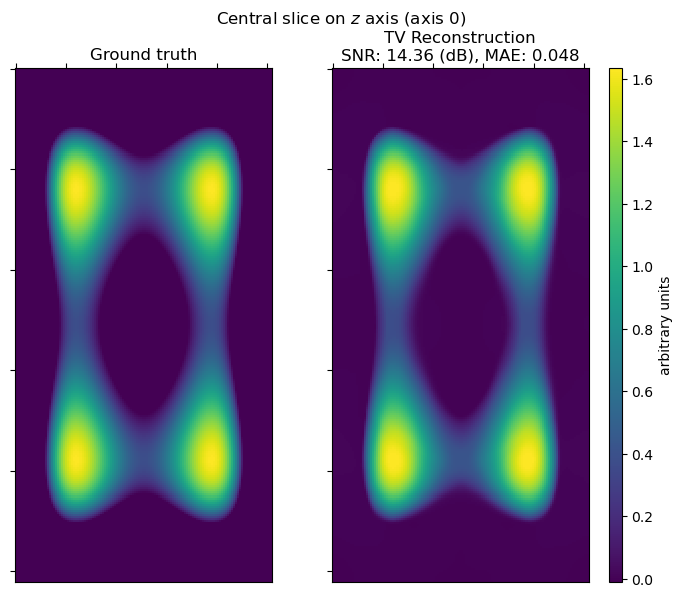

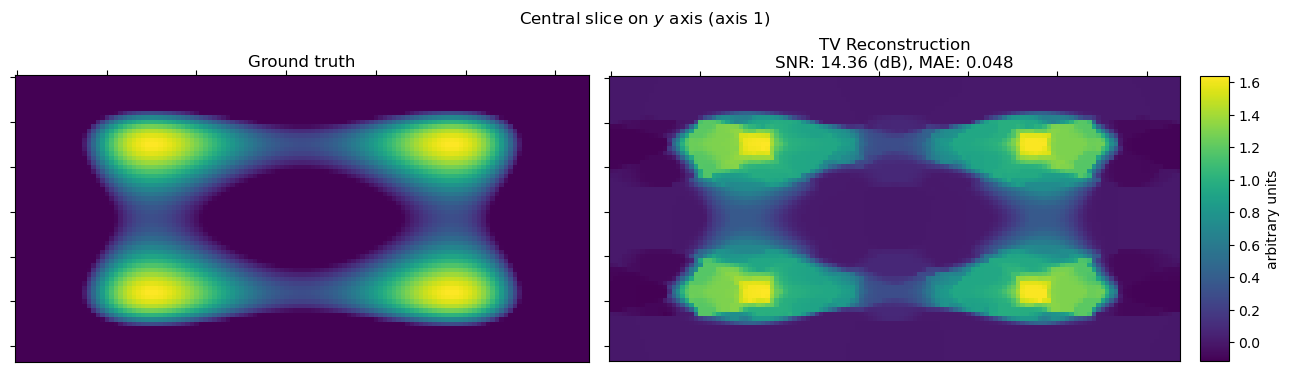

In [5]:
fig, ax = kplt.subplots(nrows=1, ncols=2, sharex=True, sharey=True, figsize=(7, 6))
kplt.imview(
    tangle[32],
    title="Ground truth",
    cmap=kplt.cm.viridis,
    show_cbar=None,
    ax=ax[0],
)
kplt.imview(
    tangle_recon[32],
    title="TV Reconstruction\nSNR: %.2f (dB), MAE: %.3f"
    % (metric.snr(tangle, tangle_recon), metric.mae(tangle, tangle_recon)),
    cmap=kplt.cm.viridis,
    ax=ax[1],
)
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.2)
fig.colorbar(ax[1].get_images()[0], cax=cax, label="arbitrary units")
fig.suptitle("Central slice on $z$ axis (axis 0)")
fig.tight_layout()
fig.show()

fig, ax = kplt.subplots(
    nrows=1,
    ncols=2,
    sharex=True,
    sharey=True,
    gridspec_kw={"width_ratios": [1, 1.08]},
    figsize=(13, 4),
)
kplt.imview(
    tangle[:, 128],
    title="Ground truth",
    cmap=kplt.cm.viridis,
    ax=ax[0],
)
kplt.imview(
    tangle_recon[:, 128],
    title="TV Reconstruction\nSNR: %.2f (dB), MAE: %.3f"
    % (metric.snr(tangle, tangle_recon), metric.mae(tangle, tangle_recon)),
    cmap=kplt.cm.viridis,
    ax=ax[1],
)
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.2)
fig.colorbar(ax[1].get_images()[0], ax=ax[1], cax=cax, label="arbitrary units")
fig.suptitle("Central slice on $y$ axis (axis 1)")
fig.tight_layout()
fig.show()